# El nigno / la nigna data


El Niño (Positive Values):

North & Northeast Brazil: Usually experiences severe drought and higher temperatures, increasing the risk of forest fires in the Amazon.

Southern Brazil: Usually experiences excessive rainfall and flooding, which can impact agriculture and infrastructure.

La Niña (Negative Values):

South Brazil: High risk of drought, which is often devastating for corn and soybean crops.

North & Northeast Brazil: Generally sees increased rainfall, which can lead to river flooding in the Amazon basin.

In [7]:
import pandas as pd
import requests
import io

def get_oni_data():
    url = "https://psl.noaa.gov/data/correlation/oni.data"
    response = requests.get(url)

    # The file has header lines and footer metadata we need to skip
    lines = response.text.split('\n')

    # Filter lines that start with a year (1950 onwards)
    data_lines = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 13 and parts[0].isdigit() and int(parts[0]) >= 1950:
            data_lines.append(line)

    # Load into DataFrame
    columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df = pd.DataFrame([l.split()[:13] for l in data_lines], columns=columns)
    df = df.set_index('Year').astype(float)

    # Replace missing values (usually -99.90 or -99.99) with NaN
    df[df < -10] = None
    return df

def get_latest_value(df):
    # Flatten the dataframe to find the last non-null value
    flat_data = df.stack()
    latest_val = flat_data.iloc[-1]
    latest_period = flat_data.index[-1]
    return latest_val, latest_period

def get_brazil_alert(val):
    if val >= 0.5:
        phase = "EL NIÑO"
        # El Niño impacts: Drought in North/Northeast, Heavy Rain in South
        if val >= 1.5:
            level = "CRITICAL (Strong El Niño)"
            advice = "High risk of drought in Amazon/NE; Severe flood risk in Southern Brazil."
        else:
            level = "MODERATE (El Niño)"
            advice = "Possible water shortages in North; Increased rainfall in the South."
    elif val <= -0.5:
        phase = "LA NIÑA"
        # La Niña impacts: Rain in North/Northeast, Drought in South
        if val <= -1.5:
            level = "CRITICAL (Strong La Niña)"
            advice = "High risk of crop failure in the South (Drought); Flood risk in North/NE."
        else:
            level = "MODERATE (La Niña)"
            advice = "Drier conditions likely in the South; Wetter in North/NE."
    else:
        phase = "NEUTRAL"
        level = "LOW"
        advice = "No major ENSO-driven climate disruptions expected."

    return phase, level, advice

# Execute
try:
    data = get_oni_data()
    val, period = get_latest_value(data)
    phase, alert, advice = get_brazil_alert(val)

    print(f"--- NOAA ONI DATA ANALYSIS ---")
    print(f"Latest Data Point: {period[0]} - {period[1]}")
    print(f"ONI Value: {val}")
    print(f"ENSO Phase: {phase}")
    print(f"-------------------------------")
    print(f"BRAZIL ALERT LEVEL: {alert}")
    print(f"IMPACT FORECAST: {advice}")
except Exception as e:
    print(f"Error fetching data: {e}")

--- NOAA ONI DATA ANALYSIS ---
Latest Data Point: 2026 - Jan
ONI Value: -0.39
ENSO Phase: NEUTRAL
-------------------------------
BRAZIL ALERT LEVEL: LOW
IMPACT FORECAST: No major ENSO-driven climate disruptions expected.


## 1. El Niño: The Warm Phase
Occurs when the **Trade Winds** weaken or reverse direction. Warm water, usually gathered near Asia, "slides" back toward the coasts of South America (Ecuador and Peru).

* **The Mechanism:** This warm water releases heat and moisture into the atmosphere in unusual locations, shifting the position of the **Jet Stream**.
* **Impact in Brazil:**
    * **North and Northeast (Amazon):** Descending air is dry, preventing cloud formation.
        * *Result:* **Extreme drought and increased forest fire risk.**
    * **South:** The Jet Stream becomes blocked over Southern Brazil, leading to stationary storm systems.
        * *Result:* **Severe flooding and persistent heavy rains.**



## 2. La Niña: The Cold Phase
The exact opposite: Trade Winds become much stronger than normal, piling up even more warm water toward Asia and pulling deep, freezing water to the surface along the American coasts (**upwelling**).

* **The Mechanism:** Cold water stabilizes the air in the Eastern Pacific but "pumps" moisture toward the Indonesian archipelago and the northern part of South America.
* **Impact in Brazil:**
    * **South:** The air becomes dry, and weather fronts struggle to move into the agricultural heartland.
        * *Result:* **Prolonged drought** (critical for soybean and corn yields).
    * **North and Northeast:** Atmospheric moisture increases drastically.
        * *Result:* **Abundant rainfall** and risk of river flooding.



## 3. The ONI Index (Oceanic Niño Index)
Because the atmosphere is chaotic, we don t rely on daily temperature spikes. Instead, we use a **3-month running mean** to confirm a lasting climate trend.

### Threshold Parameters
The index measures the temperature anomaly ($\Delta T$) compared to the long-term historical average:

| State | $\Delta T$ Interval | Alert Level |
| :--- | :--- | :--- |
| **Neutral** | $-0.5\text{°C}$ to $+0.5\text{°C}$ | Low |
| **Weak** | $0.5$ to $0.9$ (or $-0.5$ to $-0.9$) | Moderate |
| **Strong** | $> 1.5$ (or $< -1.5$) | **Critical** |

---

## 4. Why is this an "Alert" for Brazil?


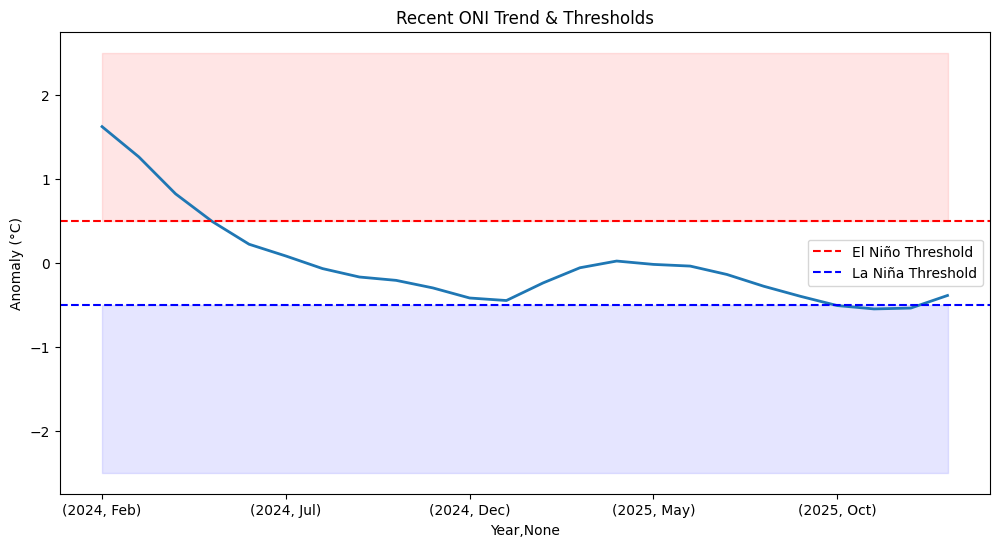

In [17]:
import matplotlib.pyplot as plt

latest_years = data.stack().tail(24)
plt.figure(figsize=(12, 6))
latest_years.plot(color='#1f77b4', lw=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='El Niño Threshold')
plt.axhline(y=-0.5, color='blue', linestyle='--', label='La Niña Threshold')
plt.fill_between(latest_years.index.map(lambda x: str(x)), 0.5, 2.5, color='red', alpha=0.1)
plt.fill_between(latest_years.index.map(lambda x: str(x)), -0.5, -2.5, color='blue', alpha=0.1)
plt.title("Recent ONI Trend & Thresholds")
plt.ylabel("Anomaly (°C)")
plt.legend()
plt.show()